# Module 2 — Composite Scoring
## Ohio Dental Clinic — Site Selection Analysis

**Purpose:** Builds and applies the weighted composite scoring model. Normalizes all four dimensions using min-max scaling and calculates weighted composite scores for all 6 locations. Competition and Medicaid scores are inverted — lower values produce higher scores.

| Dimension | Weight | Direction |
|---|---|---|
| Population (30-min) | 30% | Higher = better |
| Median Income | 30% | Higher = better |
| Competition (15-min) | 25% | Lower = better |
| Medicaid Rate | 15% | Lower = better |

| | |
|---|---|
| **Input** | `master_dataset.csv` |
| **Output** | `module2_scores.csv`, 7 chart PNGs |
| **Key finding** | Lewis Center ranks #1 with a composite score of 81.0 |

In [1]:
# LIBRARIES
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# PATHS 
DATA_PATH   = r"../outputs"
OUTPUT_PATH = r"../outputs"
CHARTS_PATH = r"../charts/charts_m2"

os.makedirs(CHARTS_PATH, exist_ok=True)

# CHART STYLE 
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        150,
})

# CONSTANTS 
WEIGHTS = {
    "population":  0.30,
    "income":      0.30,
    "competition": 0.25,
    "medicaid":    0.15,
}

COLORS = ["#0F2240", "#0D8C7A", "#E8A730", "#C0392B", "#5B5EA6", "#2E86AB"]

COLOR_MAP = {
    "Ontario":       "#0F2240",
    "Westerville":   "#0D8C7A",
    "Sawmill Rd":    "#E8A730",
    "Lewis Center":  "#C0392B",
    "Indianola Ave": "#5B5EA6",
    "Hamilton Rd":   "#2E86AB",
}

print("Setup complete.")

Setup complete.


In [2]:
# LOAD MODULE 1 OUTPUTS 
# master_dataset.csv already contains competitor columns from Module 1.
# When pandas merges two dataframes sharing column names it appends _x/_y.
# We strip _x suffixes to restore clean names and drop _y duplicates.

master      = pd.read_csv(os.path.join(DATA_PATH, "master_dataset.csv"))
competitors = pd.read_csv(os.path.join(DATA_PATH, "competitors_summary.csv"))

# Clean up _x/_y suffixes if present
rename_map = {c: c.replace("_x", "") for c in master.columns if c.endswith("_x")}
master = master.rename(columns=rename_map)
master = master[[c for c in master.columns if not c.endswith("_y")]]

df = master.copy()
print(f"Working table: {len(df)} rows x {len(df.columns)} columns")
print(f"Locations: {df['location_name'].tolist()}")

print("\nKey columns check:")
for col in ["total_15min", "total_30min", "medicaid_pct", "dso_15min", "solo_15min"]:
    status = "OK" if col in df.columns else "MISSING"
    print(f"  {col}: {status}")

Working table: 6 rows x 37 columns
Locations: ['Ontario', 'Westerville', 'Sawmill Rd', 'Lewis Center', 'Indianola Ave', 'Hamilton Rd']

Key columns check:
  total_15min: OK
  total_30min: OK
  medicaid_pct: OK
  dso_15min: OK
  solo_15min: OK


In [3]:
# MARKET OPPORTUNITY SCORE
# Ranks each location on a 0-100 composite score using 4 dimensions.
# Weights: Population 30% | Income 30% | Competition 25% | Medicaid 15%
# Competition and Medicaid are inverted — lower raw value = higher score.
# Each dimension is min-max normalized to 0-100 before weighting.

def normalize(series, invert=False):
    """Min-max normalize a series to 0-100. Invert = lower raw = higher score."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([50.0] * len(series), index=series.index)
    norm = (series - mn) / (mx - mn) * 100
    return 100 - norm if invert else norm

df["score_population"]  = normalize(df["total_population"])
df["score_income"]      = normalize(df["median_income"])
df["score_competition"] = normalize(df["total_15min"], invert=True)
df["score_medicaid"]    = normalize(df["medicaid_pct"], invert=True)

df["opportunity_score"] = (
    df["score_population"]  * WEIGHTS["population"] +
    df["score_income"]      * WEIGHTS["income"] +
    df["score_competition"] * WEIGHTS["competition"] +
    df["score_medicaid"]    * WEIGHTS["medicaid"]
).round(1)

df["rank"] = df["opportunity_score"].rank(ascending=False).astype(int)
df_ranked  = df.sort_values("opportunity_score", ascending=False)

# Residents per dentist
df["patients_per_dentist_15"] = (df["total_population"] / df["total_15min"]).round(0)

print("=" * 55)
print("MARKET OPPORTUNITY SCORES")
print("=" * 55)
print(f"{'Rank':<6} {'Location':<16} {'Score':>7} {'Pop':>7} "
      f"{'Inc':>7} {'Comp':>7} {'Med':>7}")
print("-" * 55)
for _, row in df_ranked.iterrows():
    print(f"  {int(row['rank']):<5} {row['location_name']:<16} "
          f"{row['opportunity_score']:>7.1f} "
          f"{row['score_population']:>7.1f} "
          f"{row['score_income']:>7.1f} "
          f"{row['score_competition']:>7.1f} "
          f"{row['score_medicaid']:>7.1f}")

# Save scores
scores_out = df_ranked[[
    "location_id", "location_name", "rank", "opportunity_score",
    "score_population", "score_income", "score_competition", "score_medicaid"
]]
scores_out.to_csv(os.path.join(OUTPUT_PATH, "module2_scores.csv"), index=False)
print(f"\nSaved: module2_scores.csv")

MARKET OPPORTUNITY SCORES
Rank   Location           Score     Pop     Inc    Comp     Med
-------------------------------------------------------
  1     Lewis Center        81.0    89.5   100.0    48.1    80.8
  2     Sawmill Rd          79.4    92.1   100.0    27.1   100.0
  3     Westerville         74.2    91.5    90.8    27.3    84.6
  4     Hamilton Rd         69.8    92.5    68.2    42.4    73.1
  5     Indianola Ave       60.0   100.0    53.9     0.0    92.3
  6     Ontario             25.0     0.0     0.0   100.0     0.0

Saved: module2_scores.csv


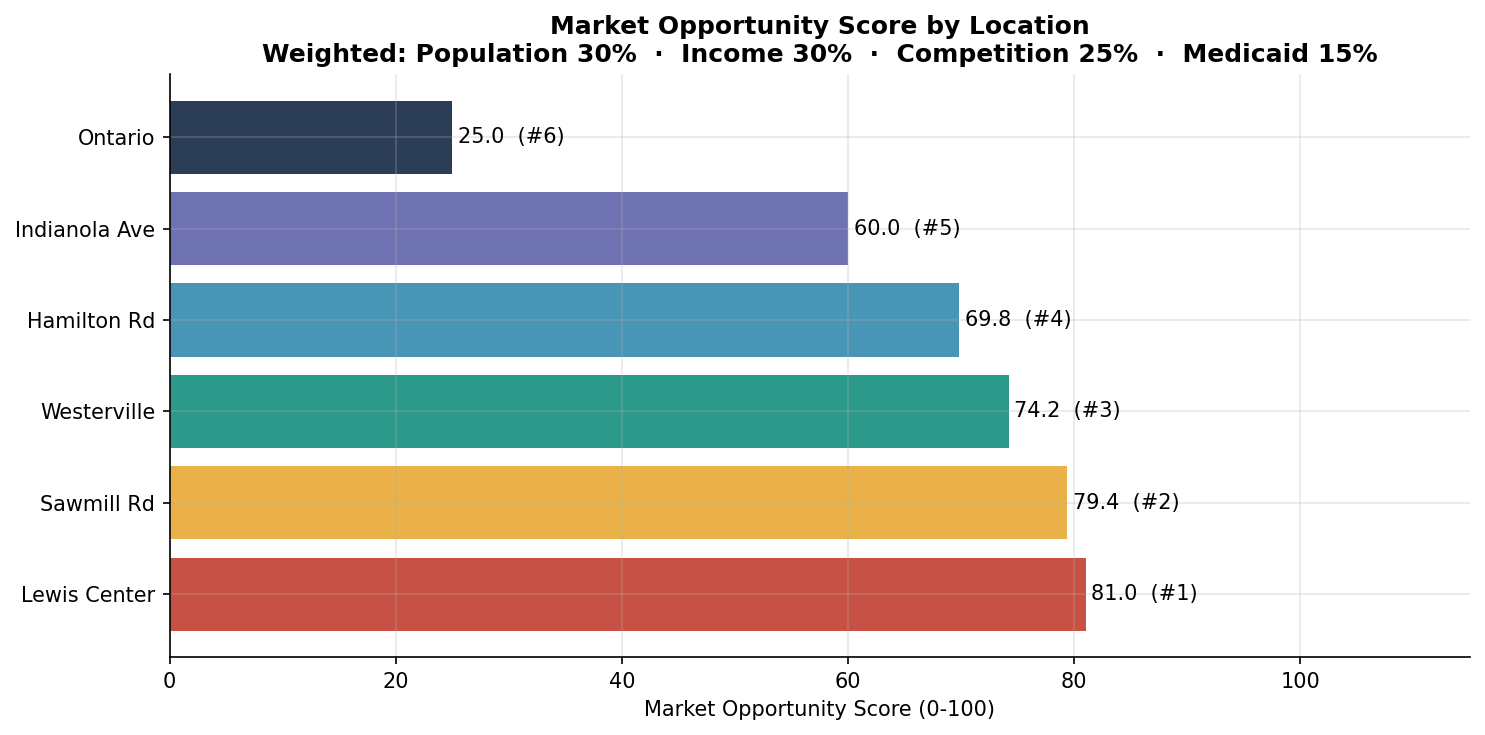

Chart 1 saved.


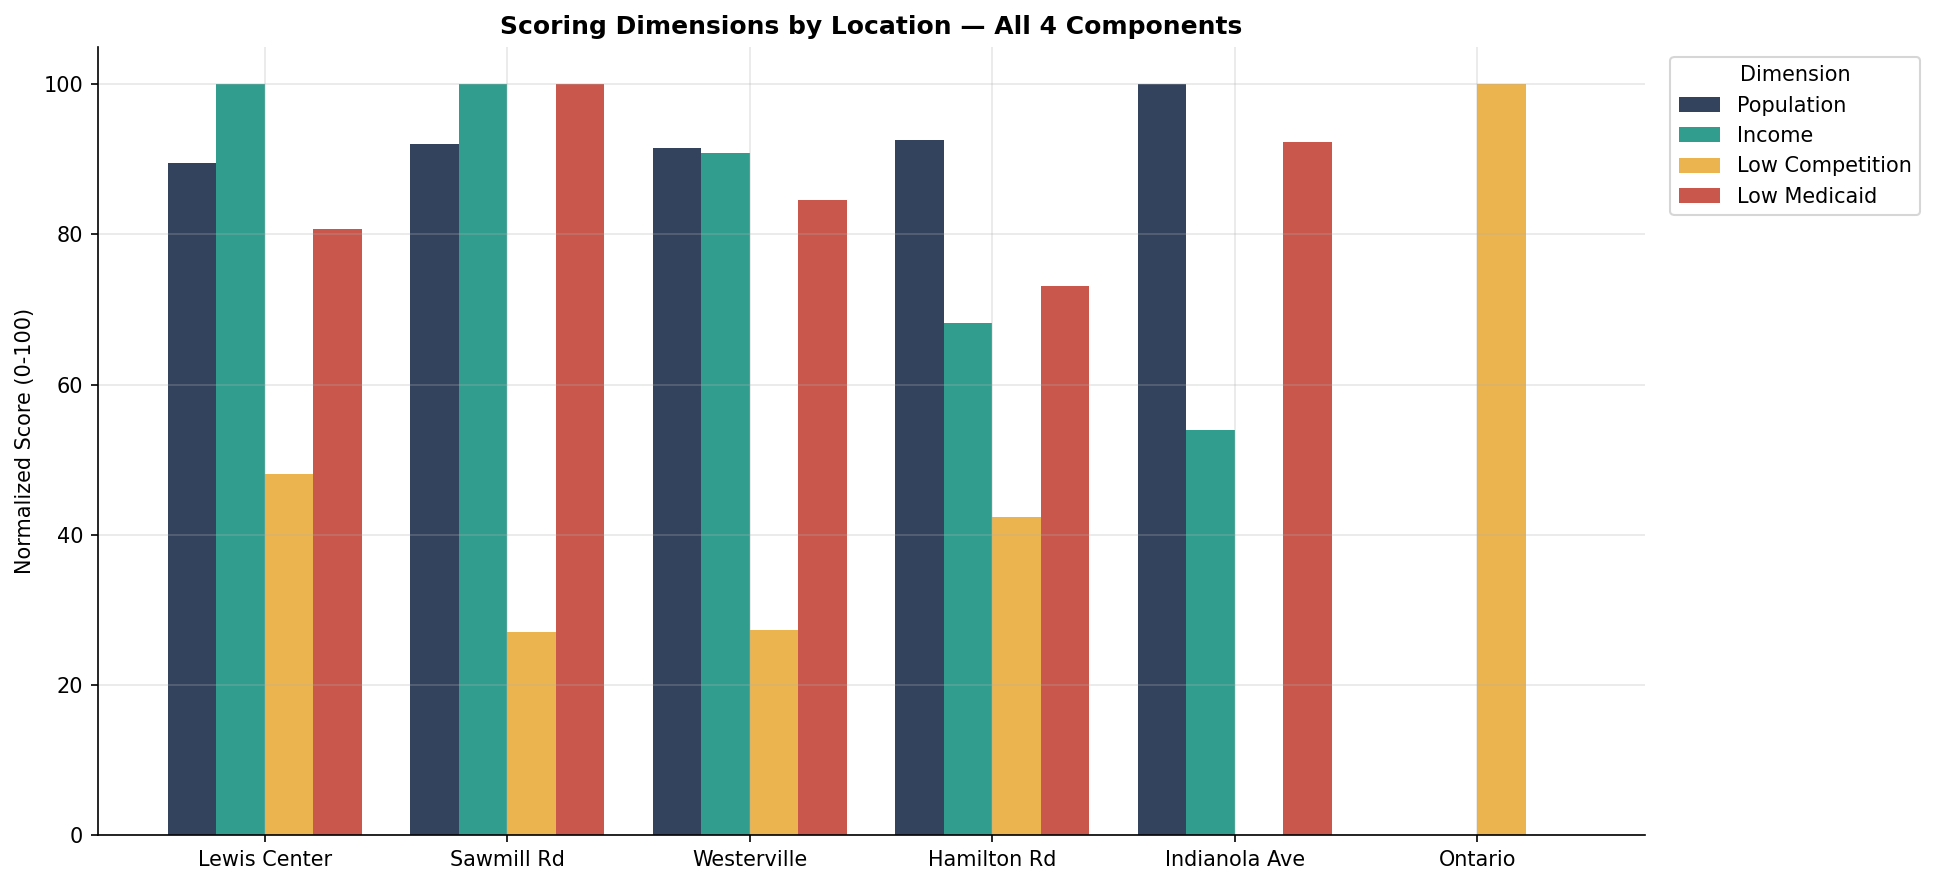

Chart 2 saved.


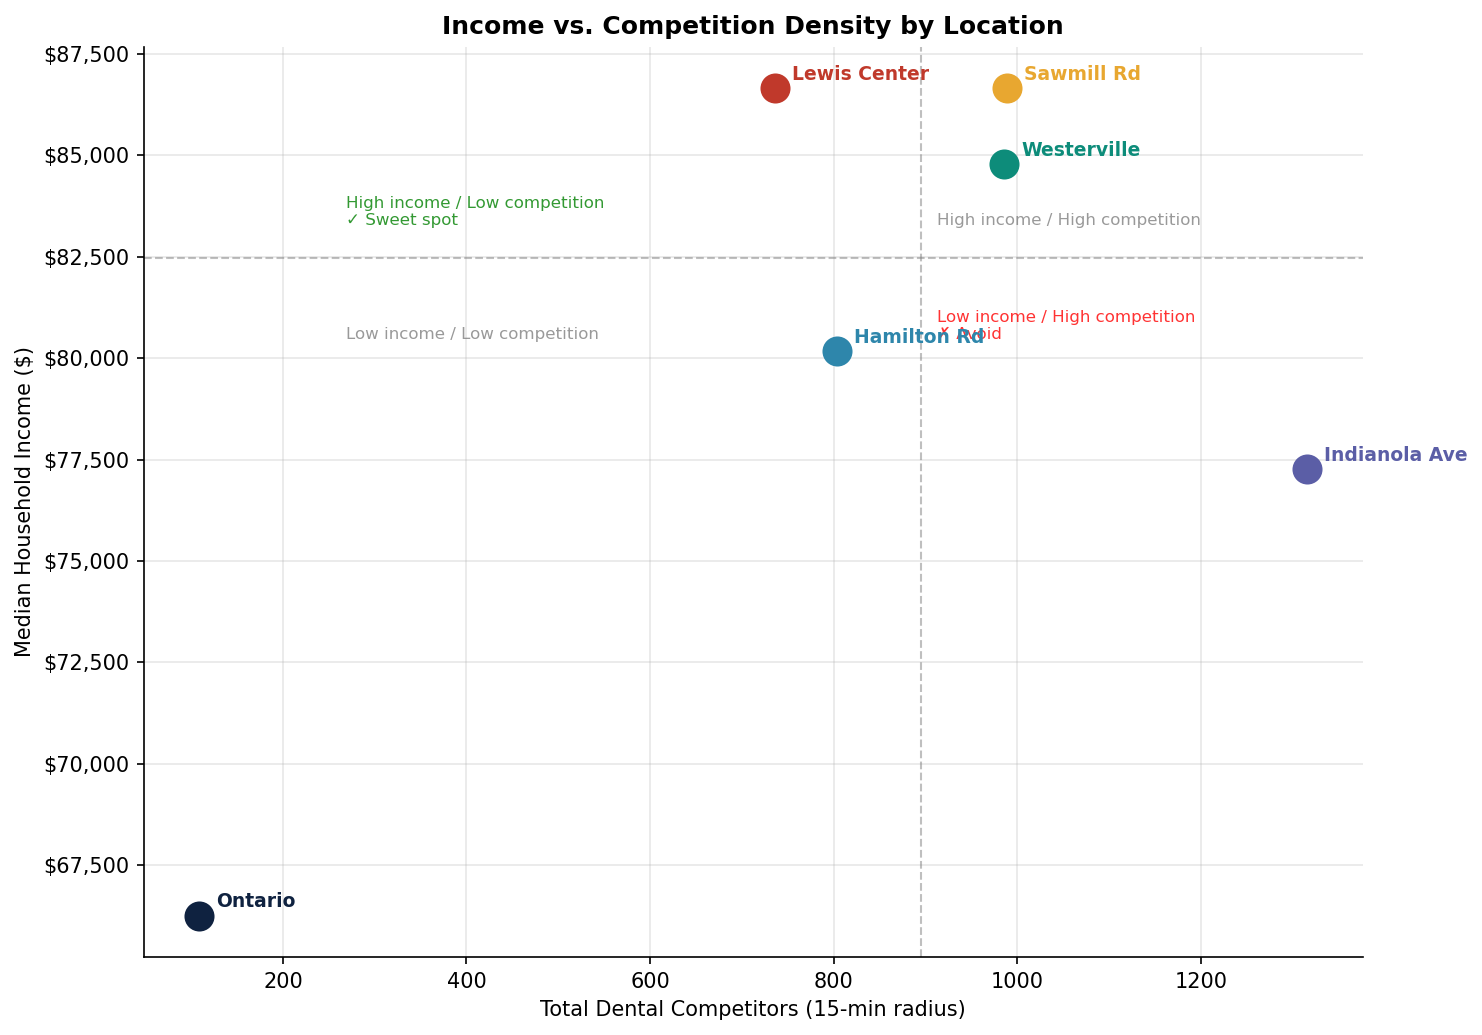

Chart 3 saved.


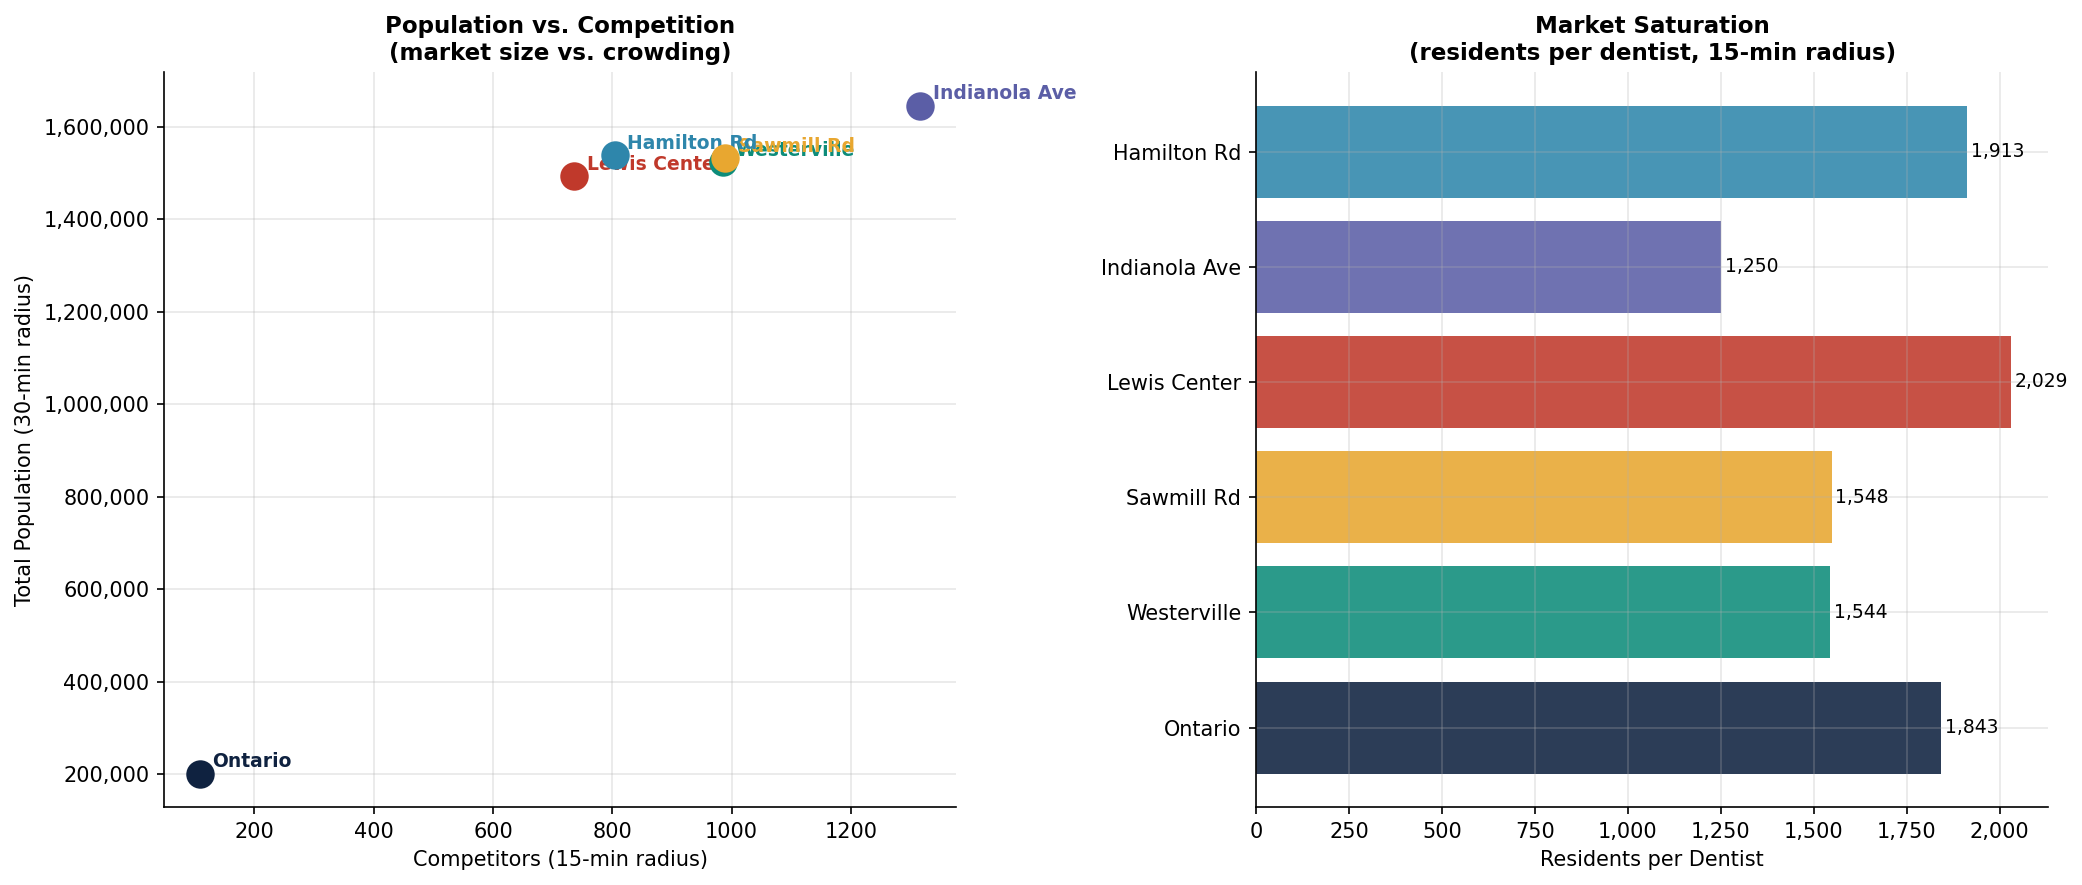

Chart 4 saved.


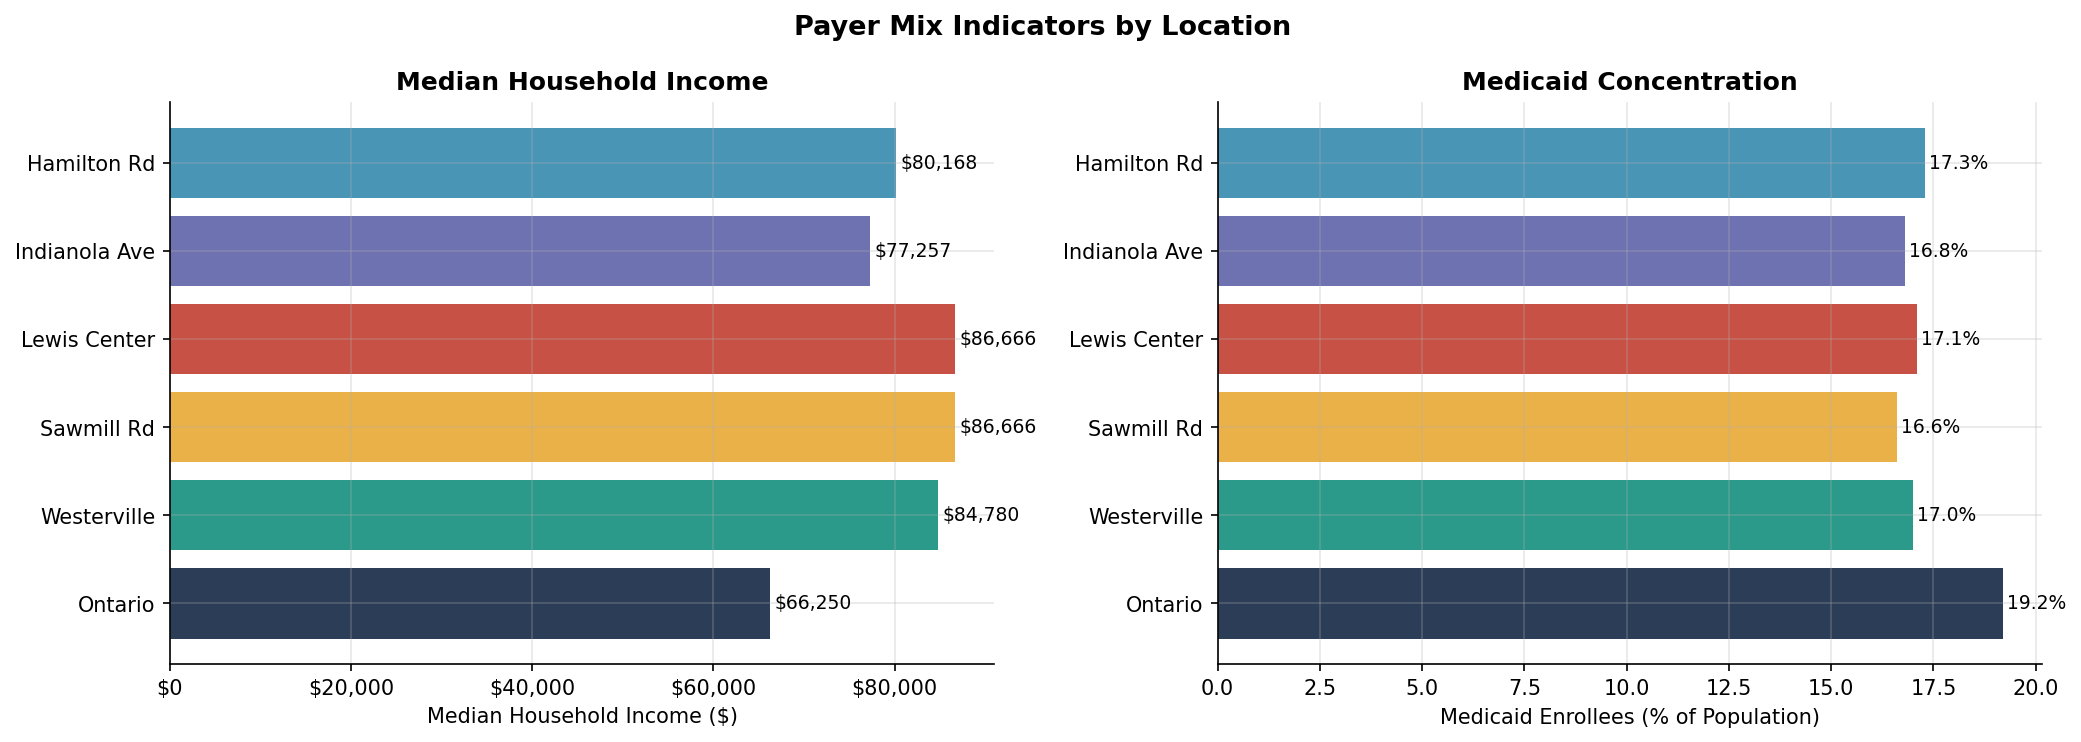

Chart 5 saved.


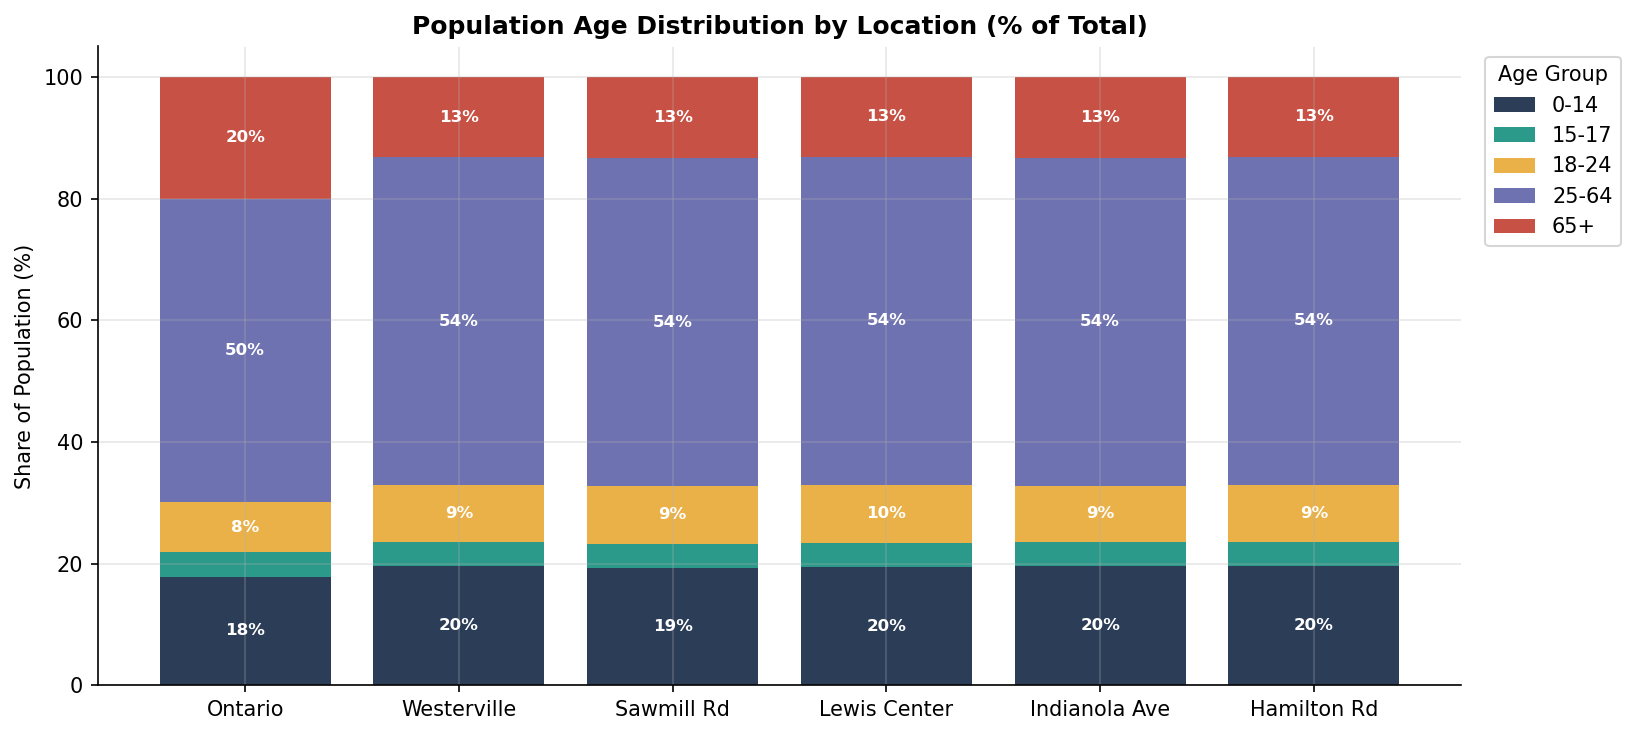

Chart 6 saved.


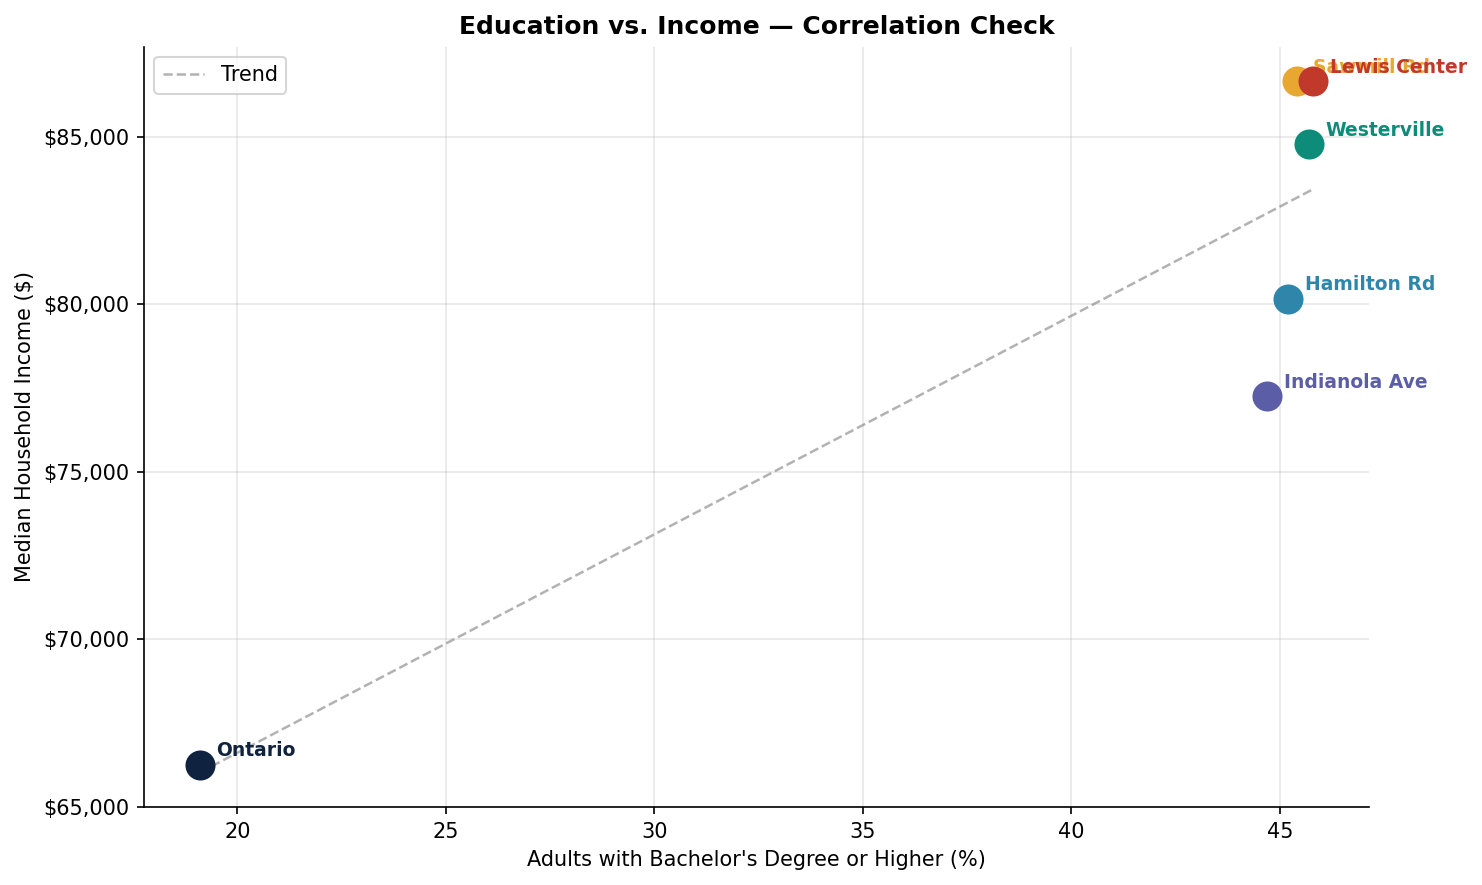

Chart 7 saved.

All charts saved to: ../charts/charts_m2


In [4]:
# CHART 1: Market Opportunity Score
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [COLOR_MAP[n] for n in df_ranked["location_name"]]
bars = ax.barh(df_ranked["location_name"], df_ranked["opportunity_score"],
               color=bar_colors, alpha=0.88)
for bar, val, rank in zip(bars, df_ranked["opportunity_score"], df_ranked["rank"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}  (#{rank})", va="center", fontsize=10)
ax.set_xlabel("Market Opportunity Score (0-100)")
ax.set_title(
    "Market Opportunity Score by Location\n"
    "Weighted: Population 30%  ·  Income 30%  ·  Competition 25%  ·  Medicaid 15%",
    fontsize=12, fontweight="bold"
)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "01_opportunity_score.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 1 saved.")

# CHART 2: Score Dimensions (Grouped Bar)
dim_cols   = ["score_population", "score_income", "score_competition", "score_medicaid"]
dim_labels = ["Population", "Income", "Low Competition", "Low Medicaid"]
dim_colors = ["#0F2240", "#0D8C7A", "#E8A730", "#C0392B"]
x, width = np.arange(len(df_ranked)), 0.20
fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, lbl, clr) in enumerate(zip(dim_cols, dim_labels, dim_colors)):
    ax.bar(x + i * width, df_ranked[col], width, label=lbl, color=clr, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_ranked["location_name"], fontsize=10)
ax.set_ylabel("Normalized Score (0-100)")
ax.set_title("Scoring Dimensions by Location — All 4 Components",
             fontsize=12, fontweight="bold")
ax.legend(title="Dimension", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "02_score_dimensions.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 2 saved.")

# CHART 3: Income vs. Competition Scatter 
fig, ax = plt.subplots(figsize=(10, 7))
median_comp   = df["total_15min"].median()
median_income = df["median_income"].median()
ax.axvline(median_comp,   color="grey", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(median_income, color="grey", linestyle="--", linewidth=1, alpha=0.5)
ax.text(median_comp * 0.3,  median_income + 800,  "High income / Low competition\n✓ Sweet spot",
        fontsize=8, color="green", alpha=0.8)
ax.text(median_comp * 1.02, median_income + 800,  "High income / High competition",
        fontsize=8, color="grey",  alpha=0.8)
ax.text(median_comp * 0.3,  median_income - 2000, "Low income / Low competition",
        fontsize=8, color="grey",  alpha=0.8)
ax.text(median_comp * 1.02, median_income - 2000, "Low income / High competition\n✗ Avoid",
        fontsize=8, color="red",   alpha=0.8)
for _, row in df.iterrows():
    clr = COLOR_MAP[row["location_name"]]
    ax.scatter(row["total_15min"], row["median_income"], color=clr, s=180, zorder=5)
    ax.annotate(row["location_name"],
                xy=(row["total_15min"], row["median_income"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=9, color=clr, fontweight="bold")
ax.set_xlabel("Total Dental Competitors (15-min radius)")
ax.set_ylabel("Median Household Income ($)")
ax.set_title("Income vs. Competition Density by Location", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "03_income_vs_competition.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 3 saved.")

# CHART 4: Market Saturation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
for _, row in df.iterrows():
    clr = COLOR_MAP[row["location_name"]]
    ax.scatter(row["total_15min"], row["total_population"], color=clr, s=160, zorder=5)
    ax.annotate(row["location_name"],
                xy=(row["total_15min"], row["total_population"]),
                xytext=(6, 3), textcoords="offset points",
                fontsize=9, color=clr, fontweight="bold")
ax.set_xlabel("Competitors (15-min radius)")
ax.set_ylabel("Total Population (30-min radius)")
ax.set_title("Population vs. Competition\n(market size vs. crowding)",
             fontsize=11, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2 = axes[1]
bar_colors = [COLOR_MAP[n] for n in df["location_name"]]
bars = ax2.barh(df["location_name"], df["patients_per_dentist_15"],
                color=bar_colors, alpha=0.88)
for bar, val in zip(bars, df["patients_per_dentist_15"]):
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", fontsize=9)
ax2.set_xlabel("Residents per Dentist")
ax2.set_title("Market Saturation\n(residents per dentist, 15-min radius)",
              fontsize=11, fontweight="bold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "04_market_saturation.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 4 saved.")

# CHART 5: Payer Mix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = [COLOR_MAP[n] for n in df["location_name"]]
bars = axes[0].barh(df["location_name"], df["median_income"], color=bar_colors, alpha=0.88)
for bar, val in zip(bars, df["median_income"]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
                 f"${val:,.0f}", va="center", fontsize=9)
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_title("Median Household Income", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
bars2 = axes[1].barh(df["location_name"], df["medicaid_pct"], color=bar_colors, alpha=0.88)
for bar, val in zip(bars2, df["medicaid_pct"]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=9)
axes[1].set_xlabel("Medicaid Enrollees (% of Population)")
axes[1].set_title("Medicaid Concentration", fontweight="bold")
plt.suptitle("Payer Mix Indicators by Location", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "05_payer_mix.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 5 saved.")

# CHART 6: Age Distribution (Stacked %) 
age_cols   = ["pop_0_14", "pop_15_17", "pop_18_24", "pop_25_64", "pop_65_plus"]
age_labels = ["0-14", "15-17", "18-24", "25-64", "65+"]
age_colors = ["#0F2240", "#0D8C7A", "#E8A730", "#5B5EA6", "#C0392B"]
age_pct = df[age_cols].div(df[age_cols].sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(df))
xpos   = np.arange(len(df))
for col, lbl, clr in zip(age_cols, age_labels, age_colors):
    vals = age_pct[col].values
    bars = ax.bar(xpos, vals, bottom=bottom, label=lbl, color=clr, alpha=0.88)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 4:
            ax.text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                    f"{val:.0f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals
ax.set_xticks(xpos)
ax.set_xticklabels(df["location_name"], fontsize=10)
ax.set_ylabel("Share of Population (%)")
ax.set_ylim(0, 105)
ax.set_title("Population Age Distribution by Location (% of Total)",
             fontsize=12, fontweight="bold")
ax.legend(title="Age Group", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "06_age_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 6 saved.")

# CHART 7: Education vs. Income Correlation 
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in df.iterrows():
    clr = COLOR_MAP[row["location_name"]]
    ax.scatter(row["pct_bachelor_plus"], row["median_income"], color=clr, s=180, zorder=5)
    ax.annotate(row["location_name"],
                xy=(row["pct_bachelor_plus"], row["median_income"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=9, color=clr, fontweight="bold")
z = np.polyfit(df["pct_bachelor_plus"], df["median_income"], 1)
p = np.poly1d(z)
xline = np.linspace(df["pct_bachelor_plus"].min(), df["pct_bachelor_plus"].max(), 100)
ax.plot(xline, p(xline), "--", color="grey", linewidth=1.2, alpha=0.6, label="Trend")
ax.set_xlabel("Adults with Bachelor's Degree or Higher (%)")
ax.set_ylabel("Median Household Income ($)")
ax.set_title("Education vs. Income — Correlation Check", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "07_education_vs_income.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 7 saved.")

print("\nAll charts saved to:", CHARTS_PATH)

In [5]:
# SUMMARY 
print("=" * 65)
print("MODULE 2 — SUMMARY STATISTICS")
print("=" * 65)

print("\n--- OPPORTUNITY SCORES (ranked) ---")
for _, row in df_ranked.iterrows():
    print(f"  #{int(row['rank'])}  {row['location_name']:<16}  "
          f"Score={row['opportunity_score']:.1f}  "
          f"Pop={row['score_population']:.1f}  "
          f"Inc={row['score_income']:.1f}  "
          f"Comp={row['score_competition']:.1f}  "
          f"Med={row['score_medicaid']:.1f}")

print("\n--- RESIDENTS PER DENTIST (15-min radius) ---")
for _, row in df.iterrows():
    print(f"  {row['location_name']:<16}  "
          f"{row['patients_per_dentist_15']:,.0f} residents per dentist")

age_cols = ["pop_0_14", "pop_15_17", "pop_18_24", "pop_25_64", "pop_65_plus"]
print("\n--- AGE DISTRIBUTION (% of catchment population) ---")
for _, row in df.iterrows():
    total = sum(row[c] for c in age_cols)
    print(f"  {row['location_name']:<16}  "
          f"0-14: {row['pop_0_14']/total*100:.1f}%  "
          f"15-17: {row['pop_15_17']/total*100:.1f}%  "
          f"18-24: {row['pop_18_24']/total*100:.1f}%  "
          f"25-64: {row['pop_25_64']/total*100:.1f}%  "
          f"65+: {row['pop_65_plus']/total*100:.1f}%")

print("\n--- PRACTICE TYPE BREAKDOWN (15-min radius) ---")
for _, row in df.iterrows():
    dso_pct = row["dso_15min"] / row["total_15min"] * 100
    print(f"  {row['location_name']:<16}  "
          f"DSO={int(row['dso_15min'])}  "
          f"Group={int(row['group_15min'])}  "
          f"Solo={int(row['solo_15min'])}  "
          f"DSO%={dso_pct:.1f}%")

print("\n--- EDUCATION ---")
for _, row in df.iterrows():
    print(f"  {row['location_name']:<16}  "
          f"Bach+={row['pct_bachelor_plus']:.1f}%")

print("\nOutputs saved:")
print(f"  {os.path.join(OUTPUT_PATH, 'module2_scores.csv')}")
print(f"  {CHARTS_PATH}/ (7 PNG files)")

MODULE 2 — SUMMARY STATISTICS

--- OPPORTUNITY SCORES (ranked) ---
  #1  Lewis Center      Score=81.0  Pop=89.5  Inc=100.0  Comp=48.1  Med=80.8
  #2  Sawmill Rd        Score=79.4  Pop=92.1  Inc=100.0  Comp=27.1  Med=100.0
  #3  Westerville       Score=74.2  Pop=91.5  Inc=90.8  Comp=27.3  Med=84.6
  #4  Hamilton Rd       Score=69.8  Pop=92.5  Inc=68.2  Comp=42.4  Med=73.1
  #5  Indianola Ave     Score=60.0  Pop=100.0  Inc=53.9  Comp=0.0  Med=92.3
  #6  Ontario           Score=25.0  Pop=0.0  Inc=0.0  Comp=100.0  Med=0.0

--- RESIDENTS PER DENTIST (15-min radius) ---
  Ontario           1,843 residents per dentist
  Westerville       1,544 residents per dentist
  Sawmill Rd        1,548 residents per dentist
  Lewis Center      2,029 residents per dentist
  Indianola Ave     1,250 residents per dentist
  Hamilton Rd       1,913 residents per dentist

--- AGE DISTRIBUTION (% of catchment population) ---
  Ontario           0-14: 17.9%  15-17: 4.0%  18-24: 8.3%  25-64: 49.9%  65+: 20.0%
  W